In [2]:
import random
import math

import pandas as pd
import seaborn as sns
import multiprocessing as mp
import matplotlib.pyplot as plt

from statistics import mean
from functools import reduce
from itertools import combinations
from copy import deepcopy
from scipy.optimize import minimize, shgo

Consts and Setup

In [3]:
eps = 1.0e-14
N = 4
M = 10
seed = 42
iterations = 2048

In [4]:
random.seed(seed)
sns.set_theme(style="whitegrid")

The Heart of Darkness

In [5]:
class DifferentialEvolution:
    def __init__(self,
                 objective_function,
                 constraint_functions,
                 upper_bounds,
                 lower_bounds,
                 population_size):
        self.objective_function = objective_function
        self.constraint_functions = constraint_functions
        self.upper_bounds = upper_bounds
        self.lower_bounds = lower_bounds
        self.population_size = population_size

    def run(self,
            stopping_condition,
            crossover,
            selection_mutation):
        self.initialize_stats()

        population = [[self.new_chromosome(upper, lower) for upper, lower in zip(self.upper_bounds, self.lower_bounds)] for _ in range(self.population_size)]
        scores = [self.evaluate(x) for x in population]
        self.update_stats(population, scores)

        while stopping_condition.check(self):
            new_generation = []
            new_scores = []

            for x, s in zip(population, scores):
                u = crossover.do(x)
                v = selection_mutation.do(x,
                                          population,
                                          self.best_solution_hist[-1],
                                          u)
                v = self.enforce_bounds(v)
                f = self.evaluate(v)

                if f < s:
                    new_generation.append(v)
                    new_scores.append(f)
                else:
                    new_generation.append(x)
                    new_scores.append(s)

            population = new_generation
            scores = new_scores
            self.iter_count += 1
            self.update_stats(population, scores)
        
        return self

    def initialize_stats(self):
        self.iter_count = 0
        self.eval_count = 0
        self.best_solution_hist = []
        self.best_score_hist = []
        self.population_diversity_hist = []

    def update_stats(self, population, scores):
        best_idx = scores.index(min(scores))

        self.best_solution_hist.append(population[best_idx])
        self.best_score_hist.append(scores[best_idx])
        self.population_diversity_hist.append(self.diversity(population))

    def new_chromosome(self, upper, lower):
        return random.uniform(lower, upper)
    
    def enforce_bounds(self, x):
        return [a if lower<=a and a<=upper else self.new_chromosome(upper, lower) for a, upper, lower in zip(x, self.upper_bounds, self.lower_bounds)]
    
    def evaluate(self, x):
        self.eval_count += 1

        objective_score = self.objective_function(x)
        penalty_score = sum(cf(x) for cf in self.constraint_functions)
        
        return objective_score + penalty_score

    def diversity(self, population):
        n = self.population_size
        total_dist = 0
        
        for a, b in combinations(population, r=2):
            total_dist += math.sqrt(sum([(x - y)**2 for x, y in zip(a, b)]))

        return total_dist/(n*(n-1)/2)

Stopping Conditions

In [6]:
class MaxIterationsStop:
    def __init__(self,
                 max_iterations):
        self.max_iterations = max_iterations
    
    def check(self, record):
        return record.iter_count < self.max_iterations

In [7]:
class FitnessThresholdStop:
    def __init__(self,
                 fitness_threshold):
        self.fitness_threshold = fitness_threshold
    
    def check(self, record):
        return self.fitness_threshold < record.best_score_hist[-1]

In [8]:
class NoImprovementStop:
    def __init__(self,
                 max_no_improve_iters,
                 no_improve_threshold):
        self.max_no_improve_iters = max_no_improve_iters
        self.no_improve_threshold = no_improve_threshold
    
    def check(self, record):
        if self.max_no_improve_iters < record.iter_count:
            window = record.best_score_hist[-self.max_no_improve_iters:]
            improves = [abs(b - a) for a, b in zip(window[:-1], window[1:])]
            return not all([imp < self.no_improve_threshold for imp in improves])
        return True

Crossovers

In [9]:
class Crossover:
    def __init__(self, p):
        self.p = p
    
    def do(self, x):
        d = random.randrange(len(x))
        u = [self.p < random.random() for _ in x]
        u[d] = True

        return u

In [10]:
class CrossoverSA:
    def do(self, x):
        d = random.randrange(len(x))
        u = [random.random() < random.gauss(0.5, 0.15) for _ in x]
        u[d] = True

        return u

Selections and Mutations

In [11]:
class SelectMutateRand1:
    def __init__(self,
                 omega):
        self.omega = omega

    def do(self,
           xx,
           population,
           _,
           uu):
        aa, bb, cc = random.sample(population, 3)

        return [a + self.omega*(b - c) if u else x for a, b, c, u, x in zip(aa, bb, cc, uu, xx)]

In [12]:
class SelectMutateBest2:
    def __init__(self,
                 nu,
                 omega):
        self.nu = nu
        self.omega = omega

    def do(self,
           xx,
           population,
           best,
           uu):
        aa, bb, cc, dd = random.sample(population, 4)

        return [bst + self.nu*(a - b) + self.omega*(c - d) if u else x for a, b, c, d, u, x, bst in zip(aa, bb, cc, dd, uu, xx, best)]
        

In [13]:
class SelectMutateSDE:
    def __init__(self,
                 dimension):
        self.omegas = [random.gauss(0.5, 0.15) for _ in range(dimension)]
    
    def do(self,
           xx,
           population,
           _,
           uu):
        self.omegas = [self.__evolve_omega() for _ in self.omegas]
        aa, bb, cc = random.sample(population, 3)

        return [a + o*(b - c) if u else x for a, b, c, o, u, x in zip(aa, bb, cc, self.omegas, uu, xx)]

    def __evolve_omega(self):
        o1, o2, o3 = random.sample(self.omegas, 3)

        return o1 + random.gauss(0, 0.5)*(o2 - o3)

In [14]:
class SelectMutateSDE2:
    def __init__(self,
                 dimension):
        self.nus = [random.gauss(0.5, 0.15) for _ in range(dimension)]
        self.omegas = [random.gauss(0.5, 0.15) for _ in range(dimension)]
    
    def do(self,
           xx,
           population,
           best,
           uu):
        self.nus = [self.__evolve_nu() for _ in self.nus]
        self.omegas = [self.__evolve_omega() for _ in self.omegas]
        aa, bb, cc, dd = random.sample(population, 4)

        return [bst + nu*(a - b) + om*(c - d) if u else x for a, b, c, d, u, x, bst, nu, om in zip(aa, bb, cc, dd, uu, xx, best, self.nus, self.omegas)]

    def __evolve_nu(self):
        n1, n2, n3 = random.sample(self.nus, 3)

        return n1 + random.gauss(0, 0.5)*(n2 - n3)

    def __evolve_omega(self):
        o1, o2, o3 = random.sample(self.omegas, 3)

        return o1 + random.gauss(0, 0.5)*(o2 - o3)

Test Functions

In [15]:
class Sphere:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([x**2 for x in xx])

In [16]:
class Rosenbrock:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([100*(x1**2-x2)**2+(1-x1)**2 for x1, x2 in zip(xx[:-1], xx[1:])])

In [17]:
class Step:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([math.floor(x) for x in xx])

In [18]:
class Griewank:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return 1 + sum([x**2 for x in xx])/4000 - reduce(lambda x, y: x*y, [math.cos(x/math.sqrt(i+1)) for i, x in enumerate(xx)])

In [19]:
class StyblinskiTang:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return sum([x**4-16*x**2+5*x for x in xx])/2

In [20]:
class Shekel:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    A = [[random.uniform(-M, M) for _ in range(M)] for _ in range(N)]
    C = [random.uniform(-M, M) for _ in range(M)]

    def fun(xx):
        return -sum([1 / (sum([(xx[j] - Shekel.A[j][i])**2 for j in range(N)]) + Shekel.C[i]) for i in range(N+2)])

In [21]:
class Rastrigin:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([x**2-10*math.cos(2*math.pi*x)+10 for x in xx])

In [22]:
class Ackley:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return -20*math.exp(-0.2*math.sqrt(mean([x**2 for x in xx])))-math.exp(mean([math.cos(2*math.pi*x) for x in xx]))+math.e+20

In [23]:
class RotatedElipsoid:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum(((i+1)*x)**2 for i, x in enumerate(xx))

In [24]:
class KeaneBump:
    upper_bounds = [10 for _ in range(N)]
    lower_bounds = [0 for _ in range(N)]
    
    def constraint_1(xx):
        violation = 0.75 - reduce(lambda x, y: x*y, xx)
        return max(0, violation)

    def constraint_2(xx):
        violation = sum(xx) - 7.5*len(xx)
        return max(0, violation)

    def fun(xx):
        cos_x_4 = sum([math.cos(x)**4 for x in xx])
        cos_x_2_prod = reduce(lambda x, y: x * y, [math.cos(x)**2 for x in xx])
        numerator = -abs(cos_x_4 - 2 * cos_x_2_prod)
        denominator = math.sqrt(sum((i + 1) * xx[i]**2 for i in range(len(xx))))
        if denominator == 0:
            return 0
        return numerator / denominator

Visualizer

In [25]:
class Visualizer:
    def __init__(self,
                 records,
                 names,
                 plate):
        self.data = pd.DataFrame({
            'Generation': [gen for r in records for gen in range(len(r.best_score_hist))],
            'Fitness Score': reduce(lambda x, y: x + y, [r.best_score_hist for r in records], []),
            'Population Diversity': reduce(lambda x, y: x + y, [r.population_diversity_hist for r in records], []),
            'Algorithm': reduce(lambda x, y: x + y, [[n]*len(r.best_score_hist) for n, r in zip(names, records)], [])
        })
        self.plate = plate
    
    def plot_fitness_evolution(self):
        plt.figure(figsize=(10,6))

        _ = sns.lineplot(data=self.data,
                     x='Generation',
                     y='Fitness Score',
                     hue='Algorithm',
                     dashes=False)
        
        plt.title('Fitness Evolution of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Best Fitness Score (Lower is Better)')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'plots\\FitnessScore{self.plate}.png', dpi=300)

    def plot_population_diversity(self):
        plt.figure(figsize=(10,6))

        _ = sns.lineplot(data=self.data,
                         x='Generation',
                         y='Population Diversity',
                         hue='Algorithm',
                         dashes=False)
        
        plt.title('Population Diversity of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Population Diversity')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'plots\\PopulationDiversity{self.plate}.png', dpi=300)


Benchmark Testbed

In [26]:
class TestBed:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        
        self.optimizers = []
        for test in self.tests:
            self.optimizers.append(DifferentialEvolution(test.fun,
                                                         [lambda _: 0],
                                                         test.upper_bounds,
                                                         test.lower_bounds,
                                                         20*N))
        self.optimizers.append(DifferentialEvolution(KeaneBump.fun,
                                                     [KeaneBump.constraint_1, KeaneBump.constraint_2],
                                                     KeaneBump.upper_bounds,
                                                     KeaneBump.lower_bounds,
                                                     20*N))
        
        self.tests.append(KeaneBump)
    
    def run_display(self):
        for i, optimizer in enumerate(self.optimizers):
            test_name = self.tests[i].__name__

            de_rand_1 = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                                Crossover(0.1),
                                                SelectMutateRand1(0.8))
            de_best_2 = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                                Crossover(0.1),
                                                SelectMutateBest2(0.6, 0.6))
            sde = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                          CrossoverSA(),
                                          SelectMutateSDE(N))
            sde2 = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                           CrossoverSA(),
                                           SelectMutateSDE2(N))
            
            print(f'for {test_name} DE/rand/1 found minimum {round(de_rand_1.objective_function(de_rand_1.best_solution_hist[-1]), 4)}')
            print(f'for {test_name} DE/best/2 found minimum {round(de_best_2.objective_function(de_best_2.best_solution_hist[-1]), 4)}')
            print(f'for {test_name} SDE found minimum {round(sde.objective_function(sde.best_solution_hist[-1]), 4)}')
            print(f'for {test_name} SDE2 found minimum {round(sde2.objective_function(sde2.best_solution_hist[-1]), 4)}')
            
            v = Visualizer([de_rand_1, de_best_2, sde, sde2],
                           ['DE/rand/1', 'DE/best/2', 'SDE', 'SDE2'],
                           f'{test_name}')
            v.plot_fitness_evolution()
            v.plot_population_diversity()

for Sphere DE/rand/1 found minimum 0.0
for Sphere DE/best/2 found minimum 0.0
for Sphere SDE found minimum 52.3001
for Sphere SDE2 found minimum 0.0
for Rosenbrock DE/rand/1 found minimum 0.0
for Rosenbrock DE/best/2 found minimum 0.0
for Rosenbrock SDE found minimum 0.0003
for Rosenbrock SDE2 found minimum 1775.155
for Step DE/rand/1 found minimum -24
for Step DE/best/2 found minimum -24
for Step SDE found minimum -24
for Step SDE2 found minimum -24
for Griewank DE/rand/1 found minimum 0.0074
for Griewank DE/best/2 found minimum 0.0197
for Griewank SDE found minimum 0.0
for Griewank SDE2 found minimum 0.0117
for StyblinskiTang DE/rand/1 found minimum -156.6647
for StyblinskiTang DE/best/2 found minimum -156.6647
for StyblinskiTang SDE found minimum -156.6647
for StyblinskiTang SDE2 found minimum -156.6647
for Shekel DE/rand/1 found minimum -2108.2101
for Shekel DE/best/2 found minimum -9356.6897
for Shekel SDE found minimum -21254.633
for Shekel SDE2 found minimum -3741.6477
for Rastr

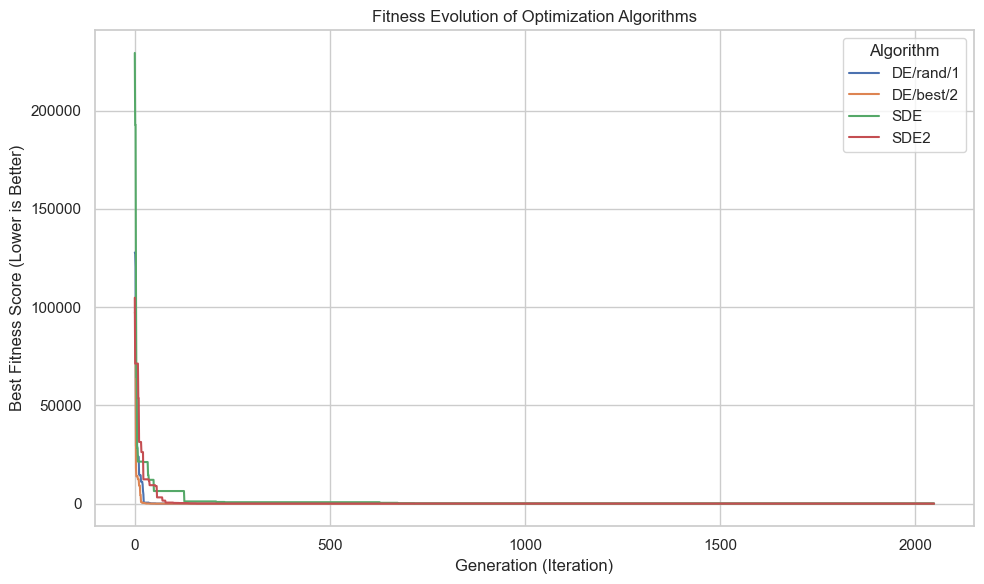

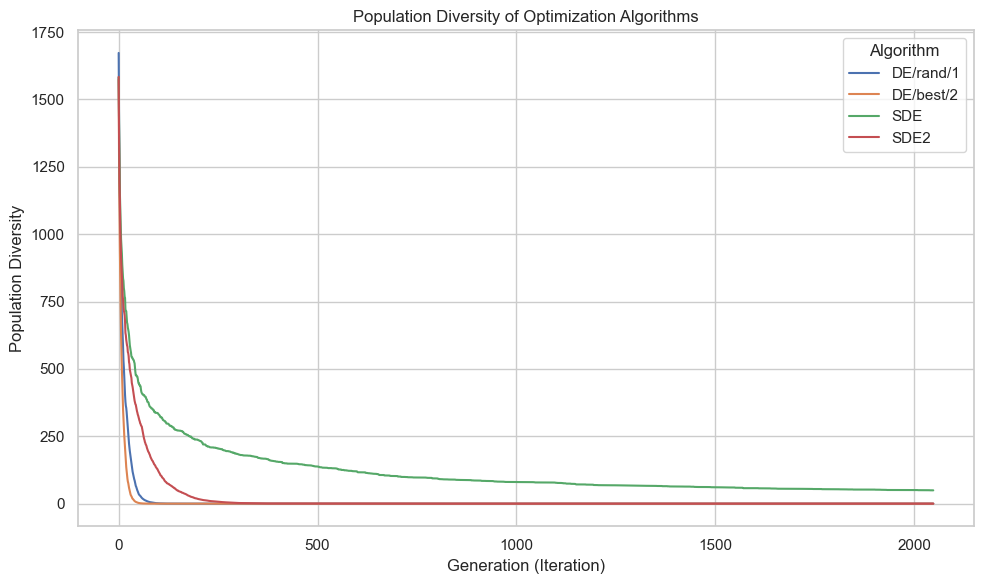

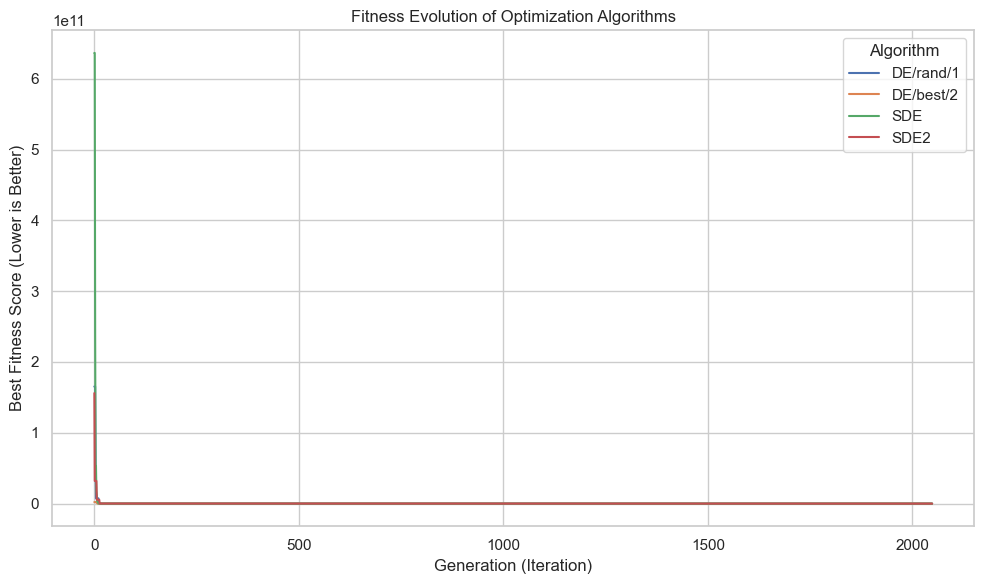

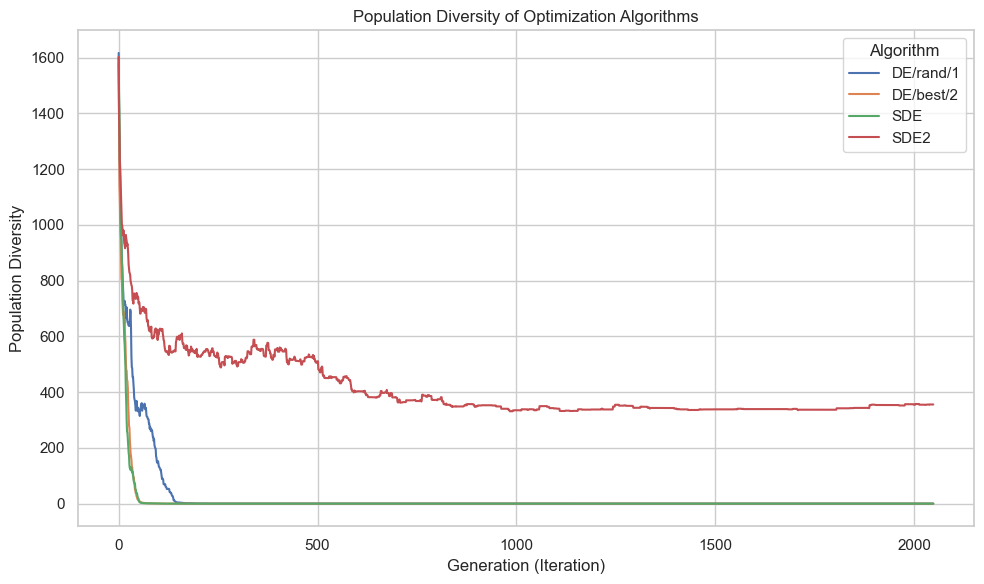

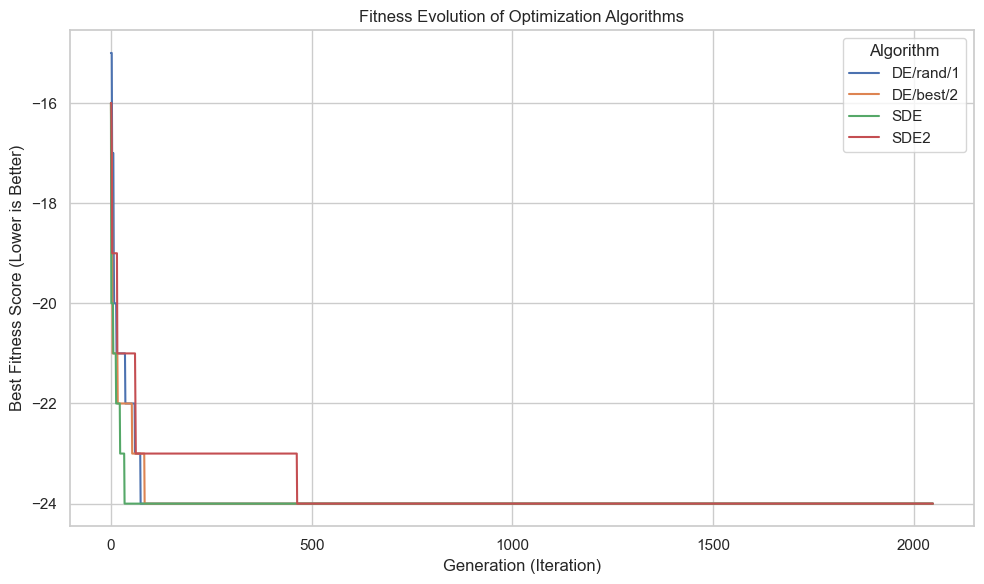

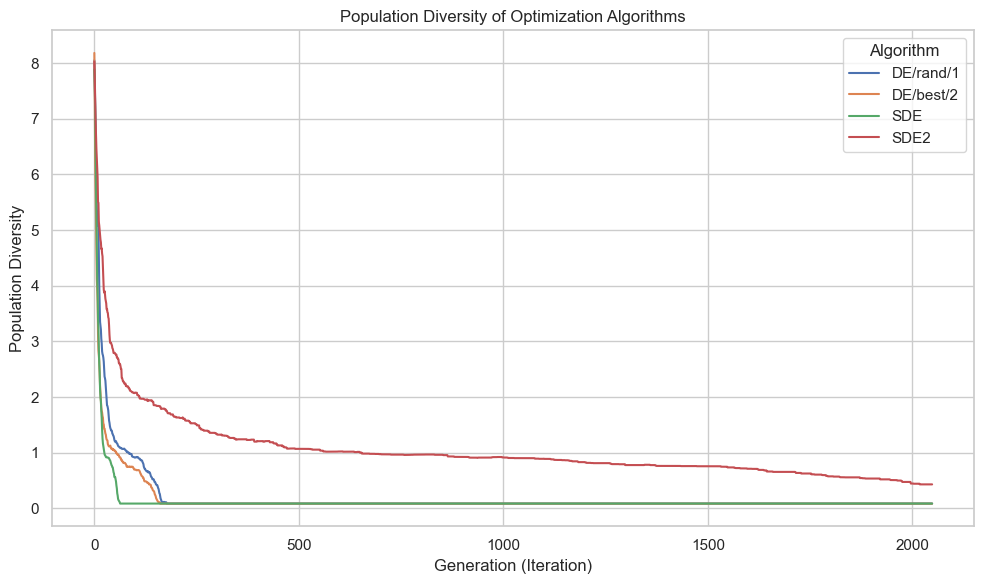

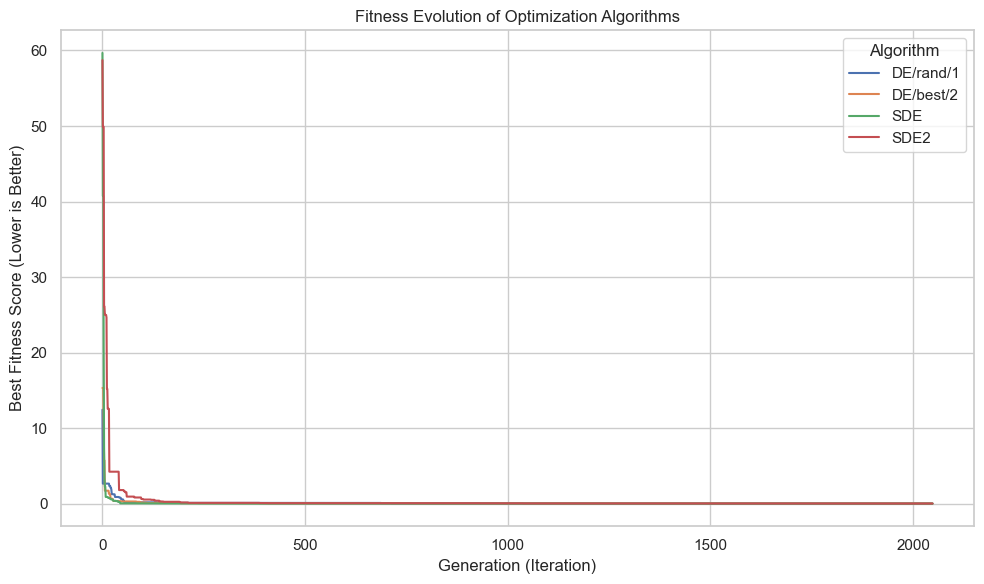

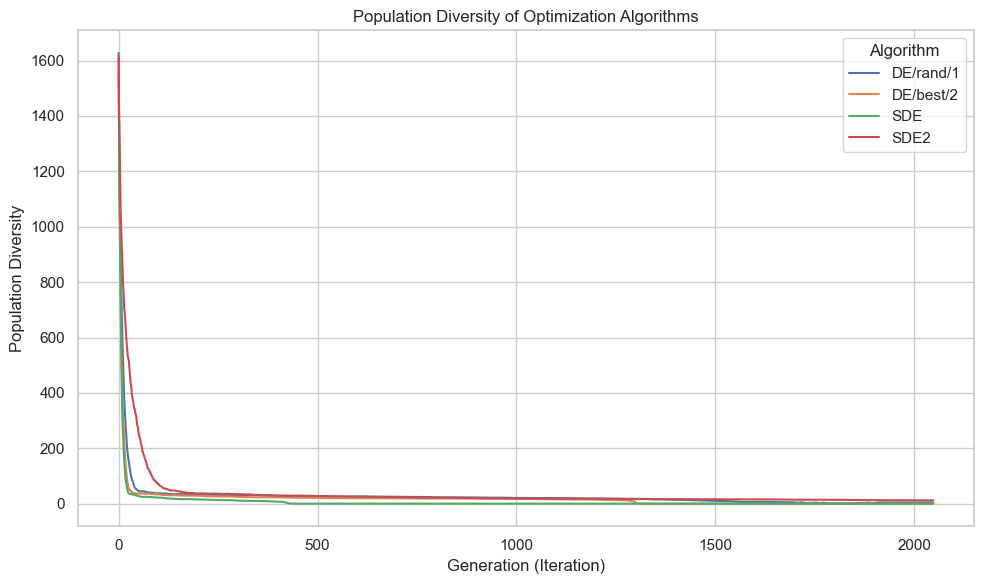

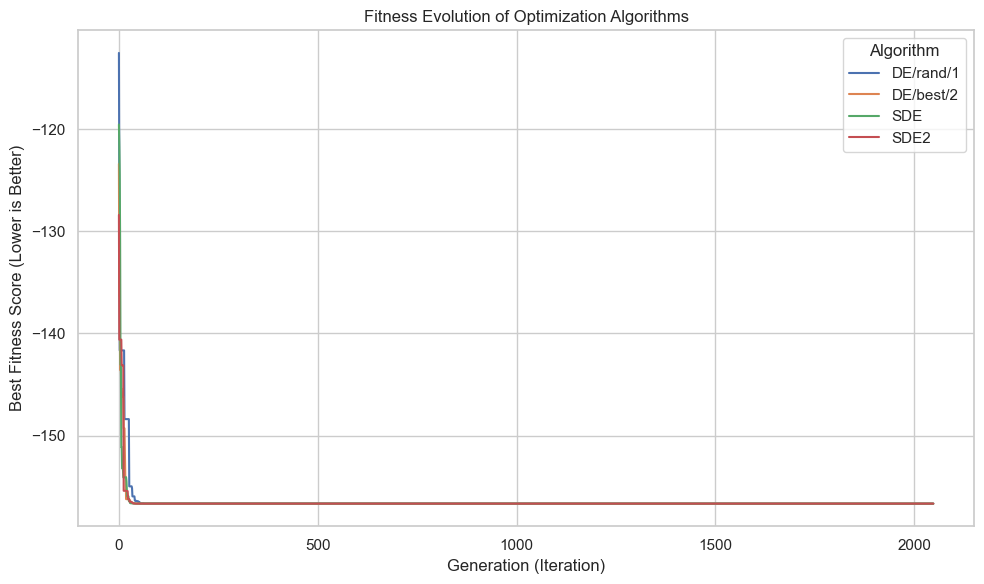

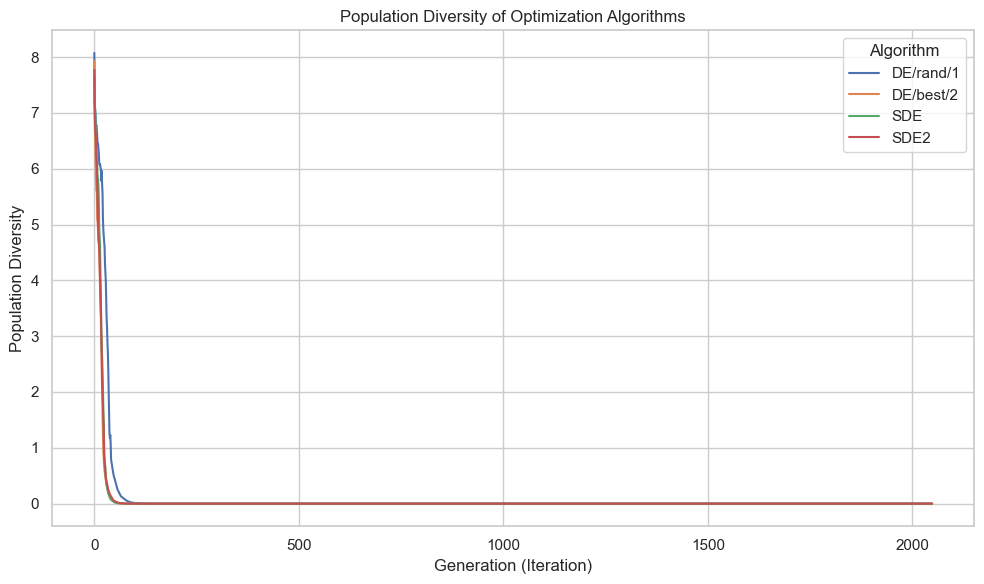

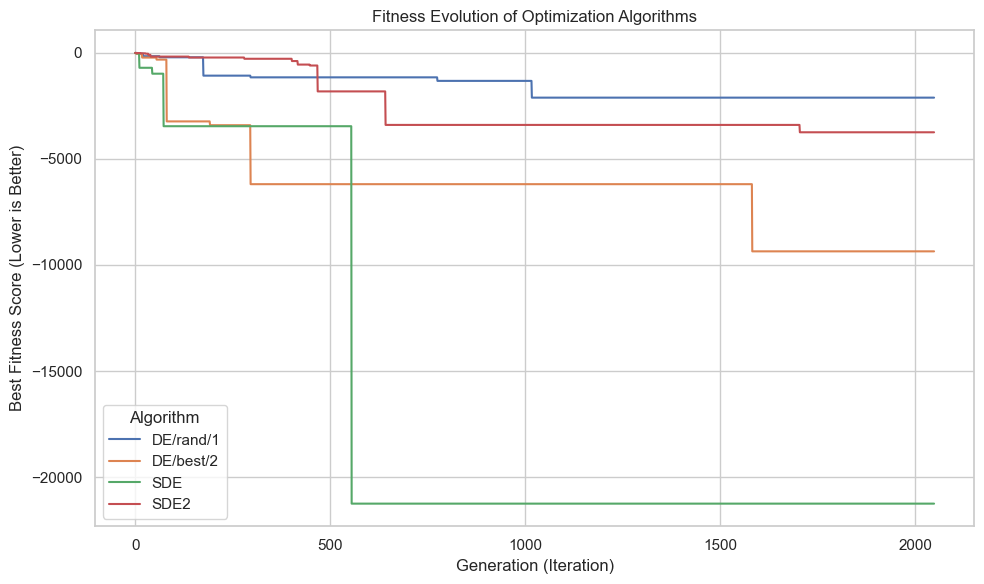

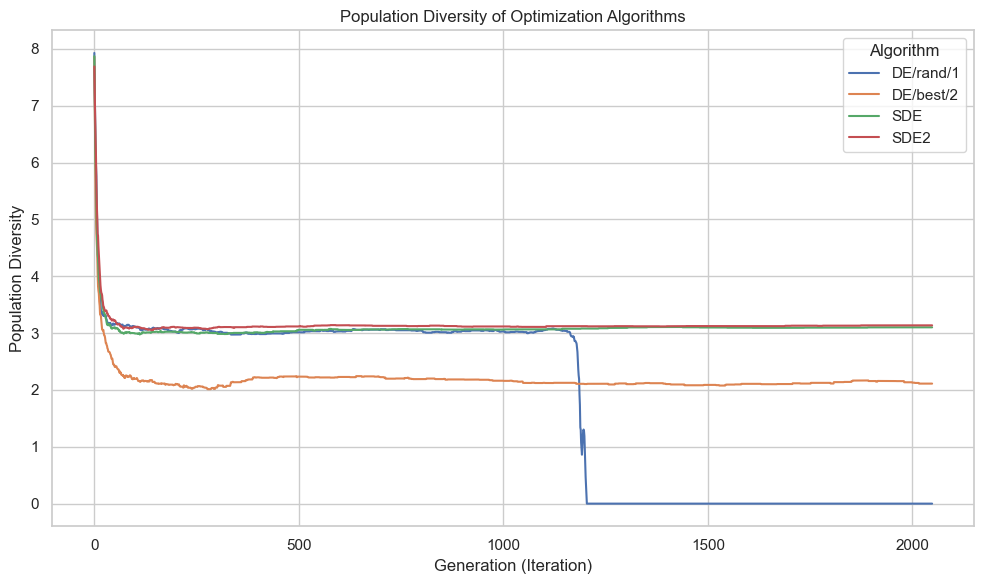

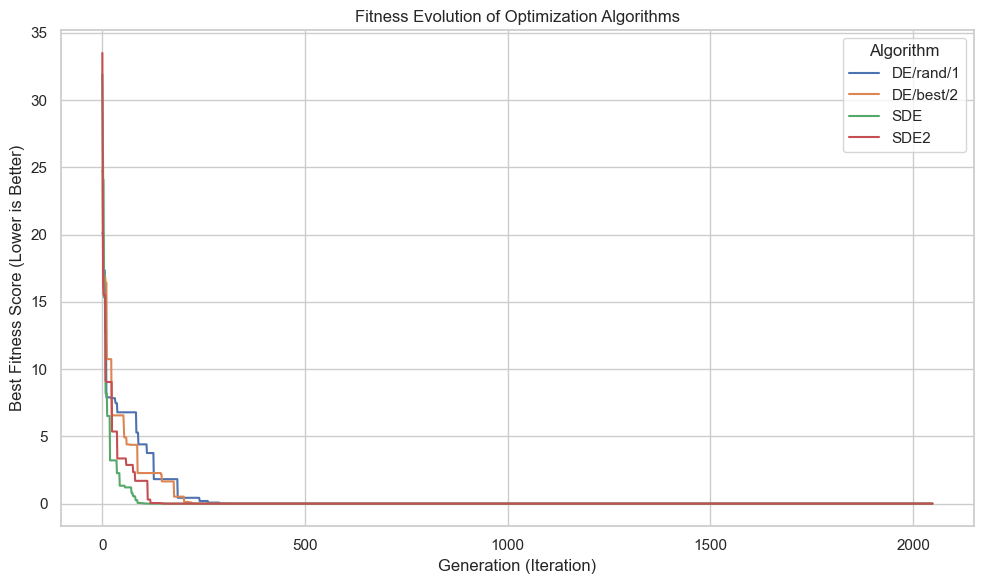

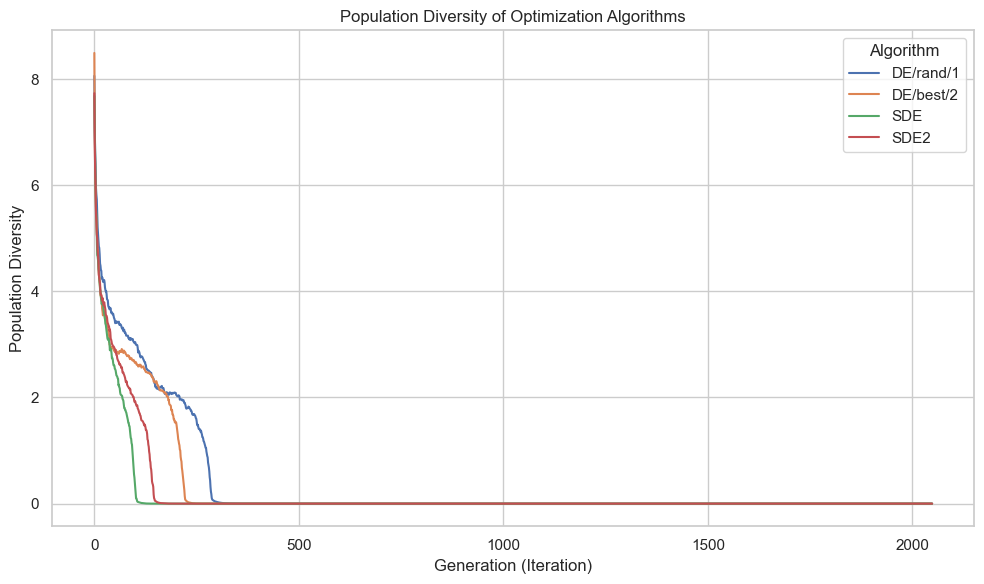

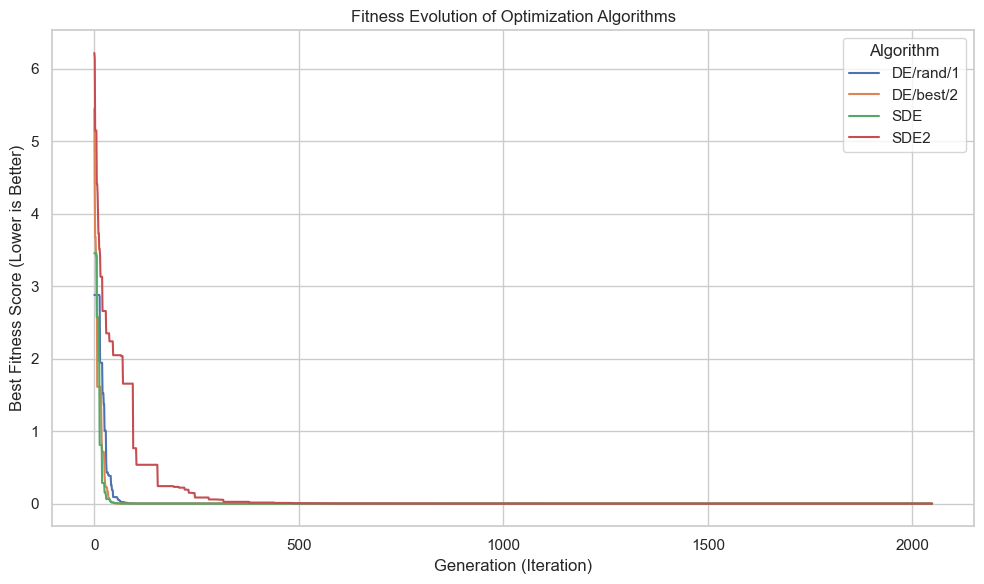

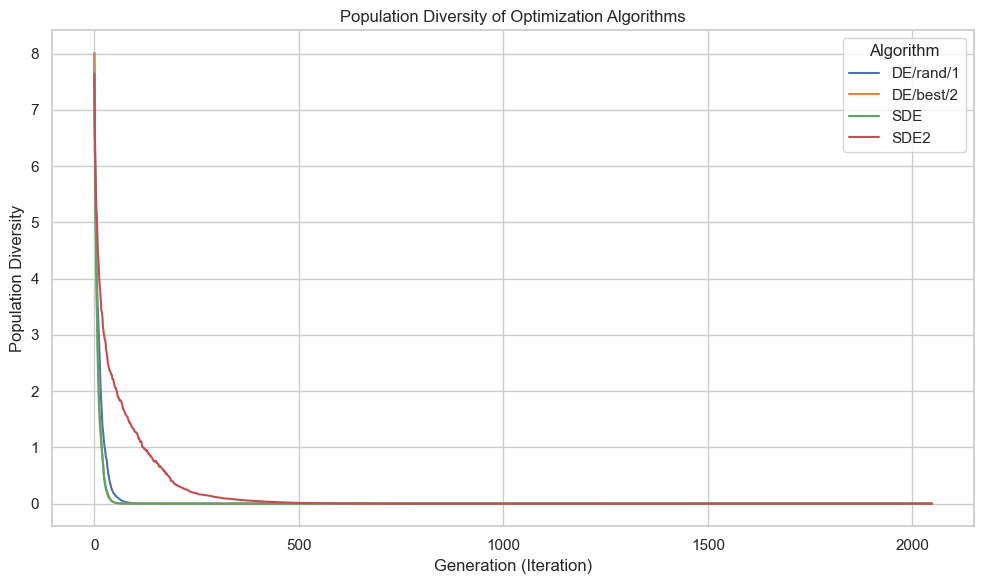

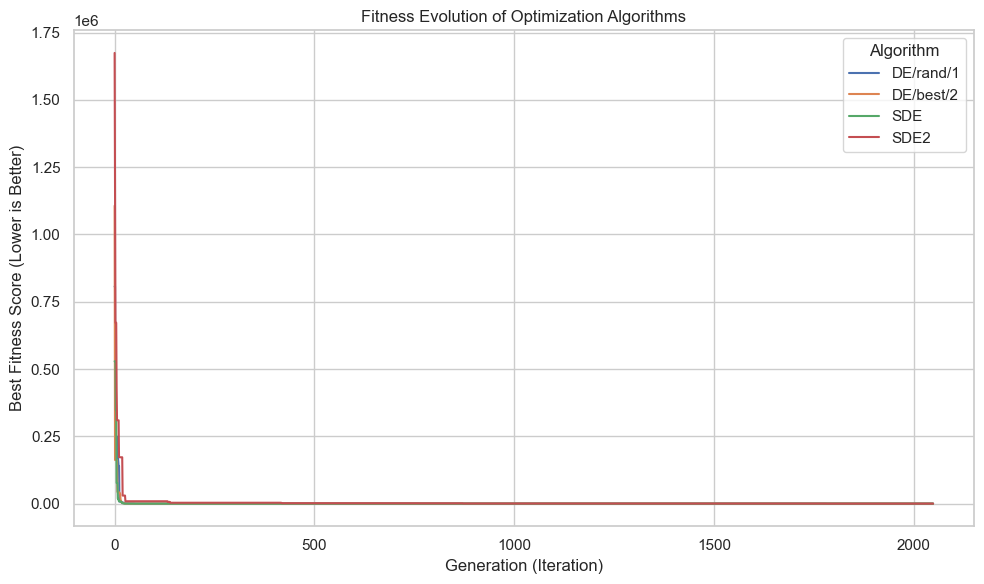

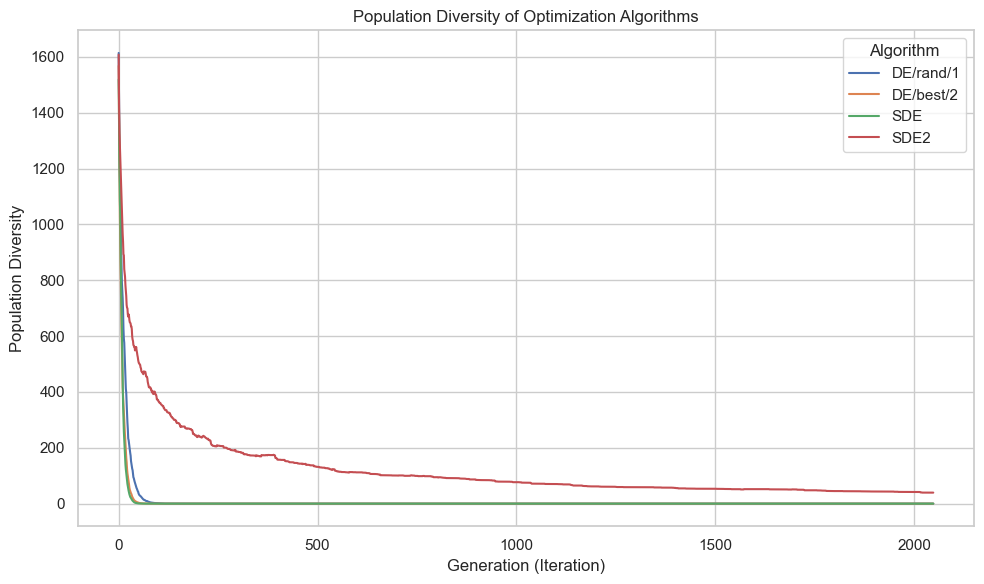

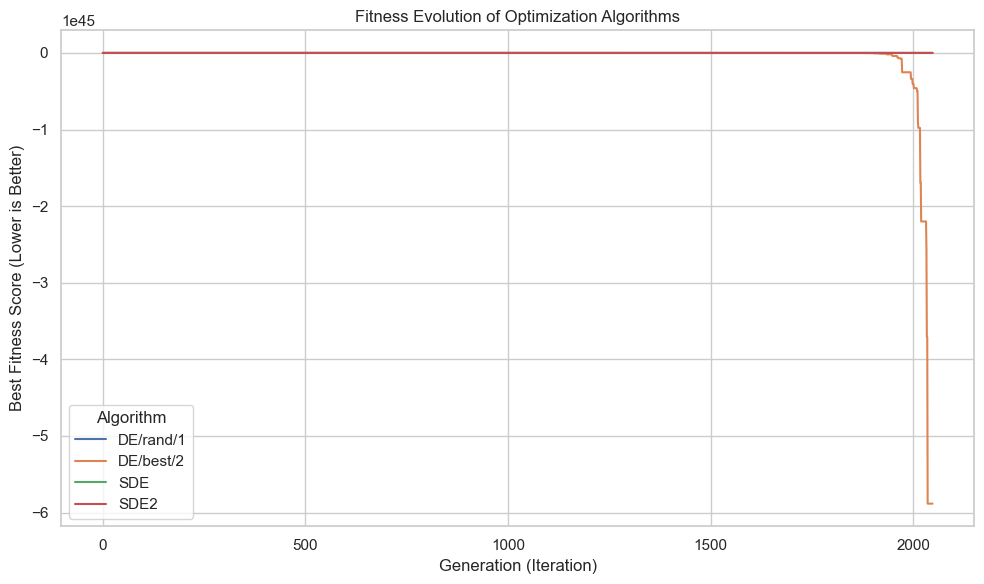

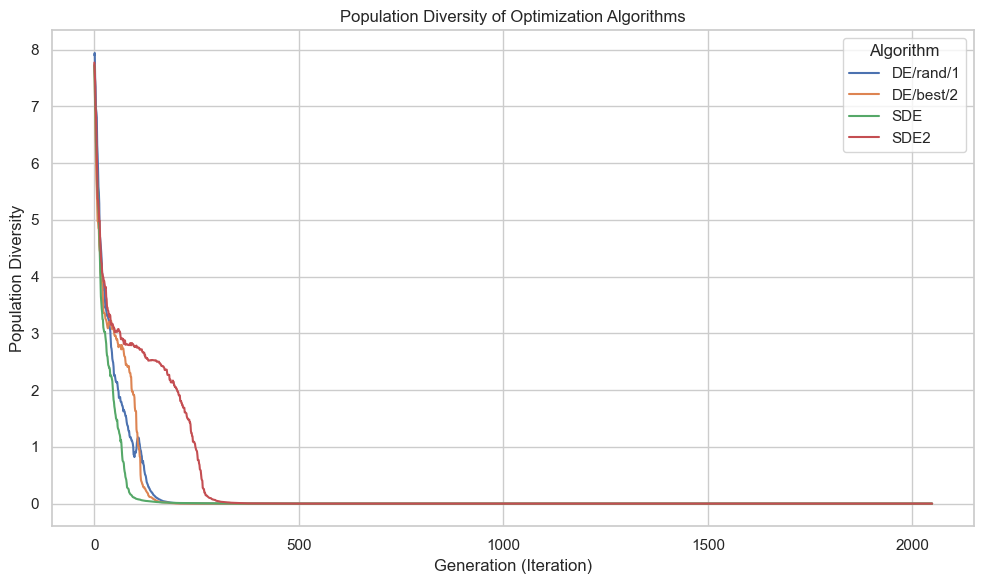

In [27]:
testbed = TestBed()
testbed.run_display()

Comparing with SciPy optimisation

In [28]:
class SciPyMinimizeTest:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        self.results = []
    
    def run(self):
        for test in self.tests:
            x0 = [random.uniform(test.lower_bounds[0], test.upper_bounds[0]) for _ in range(N)]
            self.results.append(minimize(test.fun,
                                         x0=x0,
                                         method='nelder-mead',
                                         bounds=list(zip(test.lower_bounds,
                                                         test.upper_bounds)),
                                         options={'maxiter': iterations}))
        self.results.append(minimize(KeaneBump.fun,
                                     x0=[random.uniform(test.lower_bounds[0], test.upper_bounds[0]) for _ in range(N)],
                                     method='SLSQP',
                                     bounds=list(zip(KeaneBump.lower_bounds,
                                                     KeaneBump.upper_bounds)),
                                     constraints=({'type': 'ineq', 'fun': KeaneBump.constraint_1},
                                                  {'type': 'ineq', 'fun': KeaneBump.constraint_1}),
                                     options={'maxiter': iterations}))
    
    def display_results(self):
        for test, result in zip(self.tests + [KeaneBump], self.results):
            print(f'for {test.__name__} SciPy.optimize.minimize found minimum {round(result.fun, 4)} in {result.nit} iter')

In [29]:
refer = SciPyMinimizeTest()
refer.run()
refer.display_results()

for Sphere SciPy.optimize.minimize found minimum 0.0 in 194 iter
for Rosenbrock SciPy.optimize.minimize found minimum 0.0 in 616 iter
for Step SciPy.optimize.minimize found minimum -12.0 in 16 iter
for Griewank SciPy.optimize.minimize found minimum 0.0591 in 278 iter
for StyblinskiTang SciPy.optimize.minimize found minimum -114.2545 in 124 iter
for Shekel SciPy.optimize.minimize found minimum -inf in 2048 iter
for Rastrigin SciPy.optimize.minimize found minimum 44.7729 in 80 iter
for Ackley SciPy.optimize.minimize found minimum 7.0346 in 113 iter
for RotatedElipsoid SciPy.optimize.minimize found minimum 0.0 in 194 iter
for KeaneBump SciPy.optimize.minimize found minimum -0.2088 in 1 iter


C:\Users\CTHULU\AppData\Local\Temp\ipykernel_10416\4281040258.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  return -sum([1 / (sum([(xx[j] - Shekel.A[j][i])**2 for j in range(N)]) + Shekel.C[i]) for i in range(N+2)])
c:\Python311\Lib\site-packages\scipy\optimize\_optimize.py:917: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
